# Week 3: Predictive Modeling and Algorithm Selection


## This notebook focuses on building and evaluating machine learning classification models to predict heart disease risk using clinical biomarkers.


The workflow includes data loading, feature selection, train-test splitting, model training, and performance evaluation using healthcare-focused metrics such as Recall, Precision, Confusion Matrix, and ROC-AUC score.

In [1]:
# Import libraries

import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Evaluation Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    RocCurveDisplay
)

In [2]:
# Load cleaned dataset
df = pd.read_csv(r"cleaned_heart_disease_dataset.csv")
# Display first 5 rows
df.head()

,Age,Gender,Chest_Pain_Type,Resting_Blood_Pressure,Cholesterol,Fasting_Blood_Sugar,Resting_ECG,Max_Heart_Rate,Exercise_Induced_Angina,ST_Depression,ST_Slope,Major_Vessels,Thalassemia,Heart_Disease
0,69,1,0,160,234,1,2,131,0,0.1,1,1,0,0
1,69,0,0,140,239,0,0,151,0,1.8,0,2,0,0
2,66,0,0,150,226,0,0,114,0,2.6,2,0,0,0
3,65,1,0,138,282,1,2,174,0,1.4,1,1,0,1
4,64,1,0,110,211,0,2,144,1,1.8,1,0,0,0


In [3]:
# Dataset shape
print("Dataset Shape:", df.shape)

# Column names
print("\nColumns:")
print(df.columns)

# Dataset information
df.info()

Dataset Shape: (297, 14)

Columns:
Index(['Age', 'Gender', 'Chest_Pain_Type', 'Resting_Blood_Pressure',
       'Cholesterol', 'Fasting_Blood_Sugar', 'Resting_ECG', 'Max_Heart_Rate',
       'Exercise_Induced_Angina', 'ST_Depression', 'ST_Slope', 'Major_Vessels',
       'Thalassemia', 'Heart_Disease'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 297 entries, 0 to 296
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      297 non-null    int64  
 1   Gender                   297 non-null    int64  
 2   Chest_Pain_Type          297 non-null    int64  
 3   Resting_Blood_Pressure   297 non-null    int64  
 4   Cholesterol              297 non-null    int64  
 5   Fasting_Blood_Sugar      297 non-null    int64  
 6   Resting_ECG              297 non-null    int64  
 7   Max_Heart_Rate           297 non-null    int64  
 8   Exercise_Induced_Angina  2

In [4]:
## Feature Selection
# Define features (X) and target variable (y)
X = df.drop('Heart_Disease', axis=1)
y = df['Heart_Disease']

# Display feature shape
print("Feature Shape:", X.shape)

# Display target shape
print("Target Shape:", y.shape)

Feature Shape: (297, 13)
Target Shape: (297,)


The dataset contains 13 independent features used for predicting heart disease and 1 target variable representing disease presence. The selected features include important clinical biomarkers such as cholesterol, blood pressure, chest pain type, ECG results, and exercise-induced angina. Separating the dataset into features (X) and target variable (y) prepares the data for supervised machine learning classification.

In [5]:
## Train-Test Split
# Split dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Display shapes
print("X_train Shape:", X_train.shape)
print("X_test Shape:", X_test.shape)

print("y_train Shape:", y_train.shape)
print("y_test Shape:", y_test.shape)

X_train Shape: (237, 13)
X_test Shape: (60, 13)
y_train Shape: (237,)
y_test Shape: (60,)


The dataset was divided into training and testing subsets using an 80:20 ratio. The training set contains 237 records, while the testing set contains 60 records.
This split allows the machine learning models to learn patterns from the training data and evaluate prediction performance on unseen testing data, helping ensure reliable and unbiased model evaluation.

In [6]:
#Check Class Imbalance(distribution)
print(df['Heart_Disease'].value_counts())

Heart_Disease
0    160
1    137
Name: count, dtype: int64



The dataset contains 160 healthy patients and 137 patients with heart disease, indicating a relatively balanced class distribution.
Since the difference between the two classes is minimal, the risk of model bias toward a single class is low. Therefore, advanced oversampling techniques such as SMOTE are not necessary for this analysis.

In [7]:
# Logistic Regression model

log_model = LogisticRegression(max_iter=1000)

log_model.fit(X_train, y_train)

# Predictions
y_pred_log = log_model.predict(X_test)

# Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred_log))

Accuracy: 0.7333333333333333


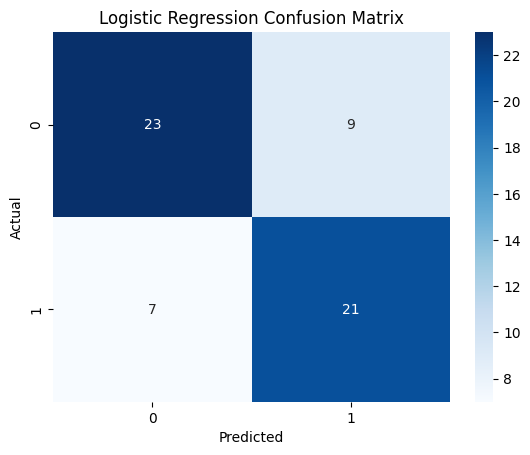

              precision    recall  f1-score   support

           0       0.77      0.72      0.74        32
           1       0.70      0.75      0.72        28

    accuracy                           0.73        60
   macro avg       0.73      0.73      0.73        60
weighted avg       0.74      0.73      0.73        60



In [8]:
# Confusion Matrix

cm = confusion_matrix(y_test, y_pred_log)

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Logistic Regression Confusion Matrix")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

# Classification Report
print(classification_report(y_test, y_pred_log))